# W3 Activity 1: Bloch Sphere

## Part 1

Before running any code, discuss or think about these questions:

1. Where is the state $|0\rangle$ on the Bloch Sphere?
### North Pole
2. Where is the state $|1\rangle$ on the Bloch Sphere?
### South Pole
3. What kind of state do you get after applying a Hadamard gate to $|0\rangle$?
### Ecuador, superposition
4. Why is the Bloch Sphere mainly used for one qubit?

### A single qubit can be mapped by two complex numbers onto the Block sphere, for more than that the number of amplitudes increase exponentially, making impossible to represents in a 3D diagram 

In [58]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector
from IPython.display import display


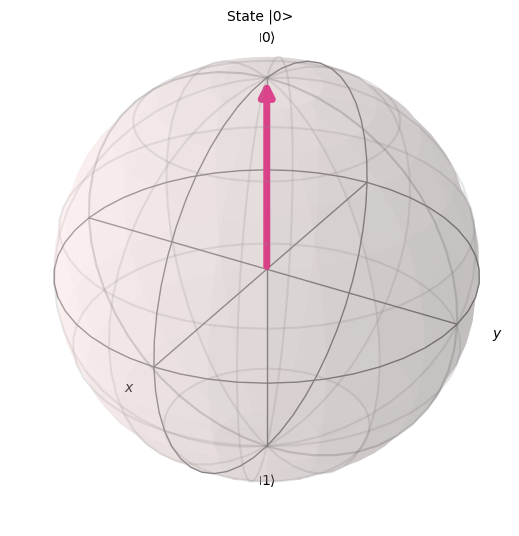

In [2]:
# |0>

plot_bloch_vector([0, 0, 1], title="State |0>")

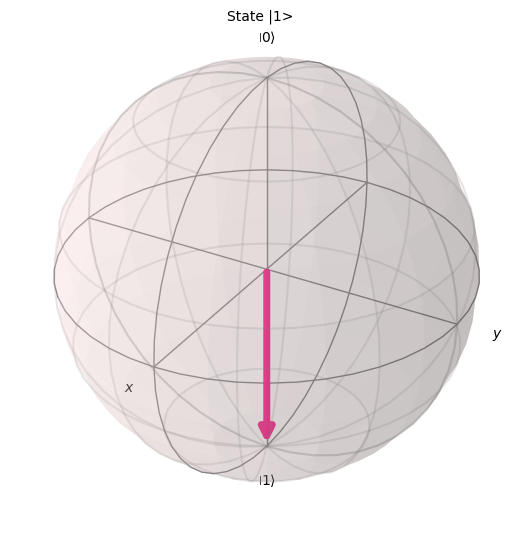

In [3]:
# |1>
plot_bloch_vector([0, 0, -1], title="State |1>")

## Reflection
1. Why is $|0\rangle$ at the top of the sphere?
### It's a mathematical representation of a qubit in state $\alpha \ket{0}  ; \alpha =1, \beta =0$
2. Why is $|1\rangle$ at the bottom?
### It's a mathematical representation of a qubit in state $\beta \ket{1}  ; \alpha =0, \beta =1$
3. What does the **z-axis** represent here?
### It shows the measurement tendency of a qubit toward `0` or `1`


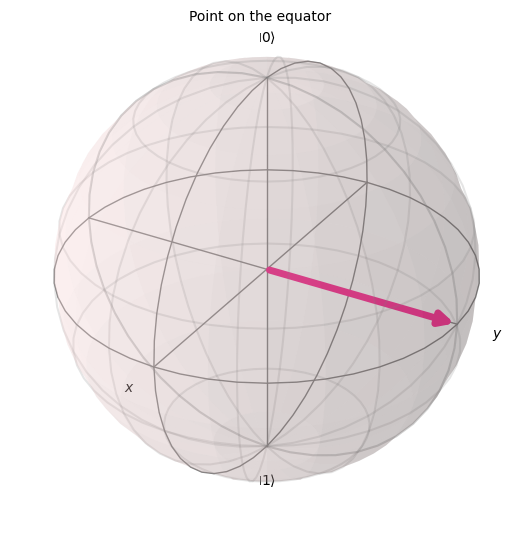

In [4]:
# Ecuador
plot_bloch_vector([0, 1, 0], title="Point on the equator")

### Reflection
1. Is this state at a pole or on the equator?
### It is on the equator, specifically on the positive y-axis.
2. What does its position suggest about the qubit?
### The vector’s position suggests that the qubit is in an equal superposition on the positive y-axis, which can be produced by applying an `S` gate after a Hadamard gate.


## Using spherical coordinates

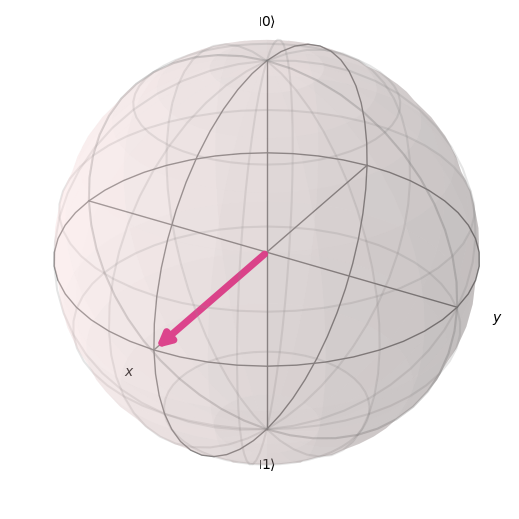

In [53]:
##
plot_bloch_vector([1, np.pi/2, 0], coord_type='spherical')

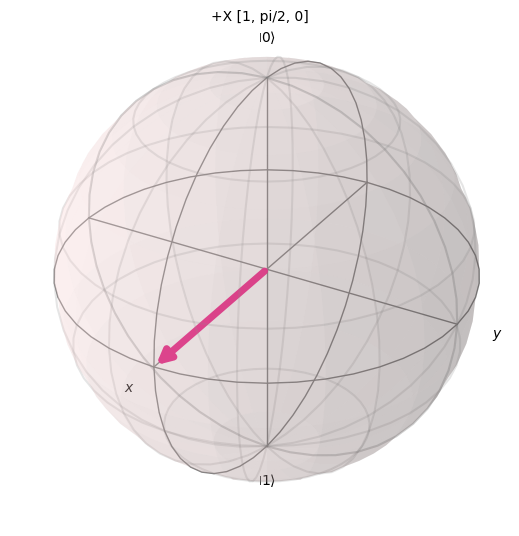

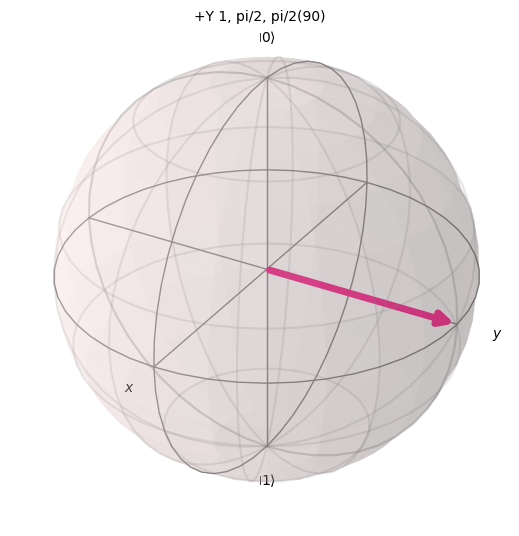

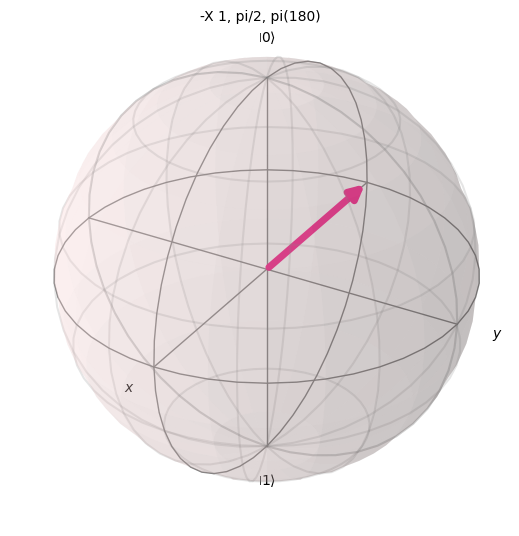

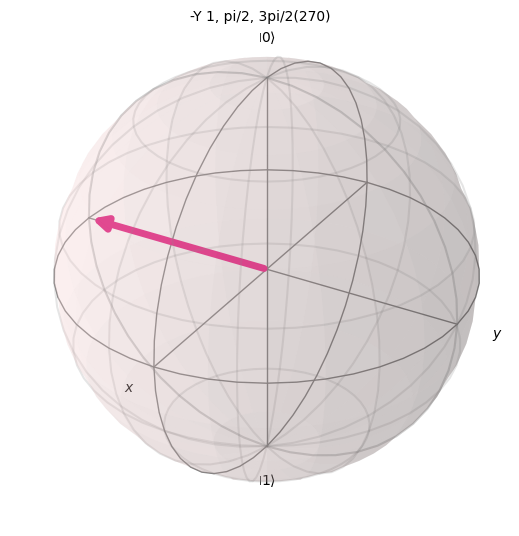

In [63]:
vectors = [
    ([1, np.pi/2, 0], "+X [1, pi/2, 0]"),
    ([1, np.pi/2, np.pi/2], "+Y 1, pi/2, pi/2(90)"),
    ([1, np.pi/2, np.pi], "-X 1, pi/2, pi(180)"),
    ([1, np.pi/2, 3*np.pi/2], "-Y 1, pi/2, 3pi/2(270)")
]

for vector, label in vectors:
    fig = plot_bloch_vector(vector, coord_type='spherical', title=label)
    display(fig)

## Reflection
1. What happens when $\theta = \pi/2$?
### Superposition state between north and south of the equator, a qubit has 50/50 probabilities of measure `1` or `0`
2. What role does $\phi$ play?
### Control the direction around the equator, represents the phase between $|0\rangle$ and $|1\rangle$
3. Why is the radius equal to 1 for a pure state?
### The state of the qubit, could be 1 0r 0, but vectorial it's always 1, so the vector has full length

x = 0.5000000000000001
y = 0.8660254037844386
z = 6.123233995736766e-17


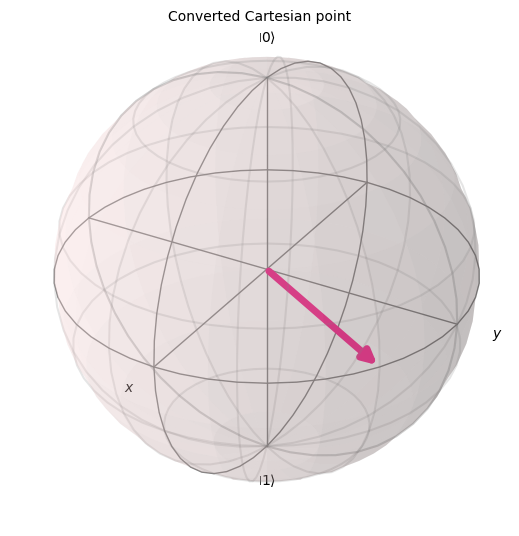

In [65]:
# Define the spherical coordinates
r = 1
theta = np.pi/2
phi = np.pi/3

# Convert spherical to Cartesian coordinates
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

print("x =", x)
print("y =", y)
print("z =", z)

plot_bloch_vector([x, y, z], title="Converted Cartesian point")



## Reflection
1. How do the Cartesian coordinates relate to the plotted point?
### `x y z` represent the position a direction of a vector on the sphere, each value shows how much the vector points along that axis
2. If you change $\theta$ to 0, where will the point move?
### To $|0\rangle$, the qubit state `0` 
3. If you change $\theta$ to $\pi$, where will the point move?
### To $|1\rangle$, the qubit state `1`


# Visualizing quantum states from circuits

   ┌───┐
q: ┤ H ├
   └───┘


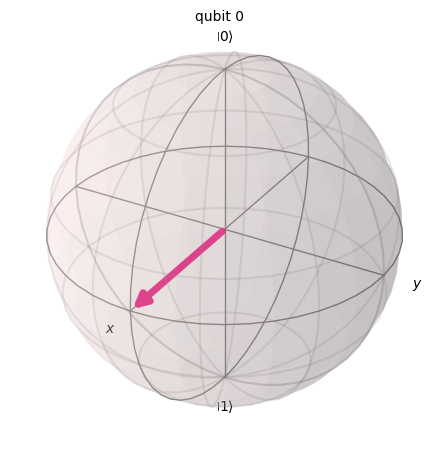

In [66]:
qc = QuantumCircuit(1)
qc.h(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

## Reflection
1. Where did the state move?
### The state moved from the north pole, $|0\rangle$, to the positive X-axis on the equator. This represents an equal superposition state
2. Why is the state no longer at the north pole?
### Because the `H` gate changed the qubit from $|0\rangle$ into an equal superposition state: $|\psi\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$ Thus, the qubit is no longer definitely `0`
3. What does this tell you about superposition?
### The `H` gate moves the qubit to the positive X-axis, where $\theta = \pi/2$, meaning the qubit has a 50% probability of being measured as `0` or `1`

# X Gate

   ┌───┐
q: ┤ X ├
   └───┘


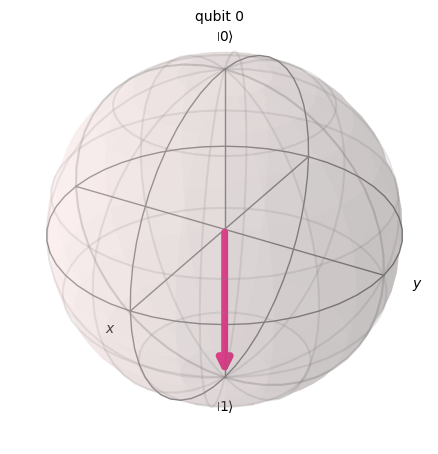

In [67]:
qc = QuantumCircuit(1)
qc.x(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

## Reflection
1. Did the state move from the north pole to the south pole?
### yes, the qubit starts in the state $|0\rangle$, which is at the north sphere. After applying the `X` gate, it changes to $|1\rangle$, which is at the south pole.
2. Why can the X gate be thought of as a bit-flip gate?
### because x swaps the amplitudes of $\alpha$ and $\beta$ in this case in particular case $X(\alpha|0\rangle + \beta|1\rangle) = \beta|0\rangle + \alpha|1\rangle$ thus, it flips $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$.

# H followed by Z

   ┌───┐┌───┐
q: ┤ H ├┤ Z ├
   └───┘└───┘


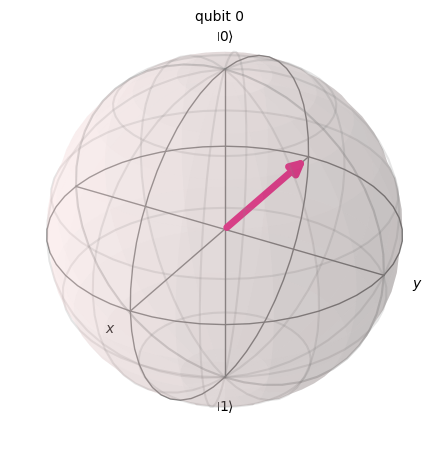

In [70]:
qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

## Reflection
1. Did the point remain on the equator?
### Yes, the point remained on the equator, but it moved to the negative X-axis.
2. What changed after the Z gate?
### The phase of $\beta$ changed flipping $Z|1\rangle = -|1\rangle$, so after `H` gate is: $Z\left|\psi\right\rangle=\frac{1}{\sqrt2}\left|0\right\rangle-\frac{1}{\sqrt2}\left|1\right\rangle$
3. Why is phase important in quantum computing?
### Manipulation of phases is important because it controls interferences between quantum states, wrong answers cancel through destructive interference and the right answer is amplified. 

# Compare a few gates


H
   ┌───┐
q: ┤ H ├
   └───┘


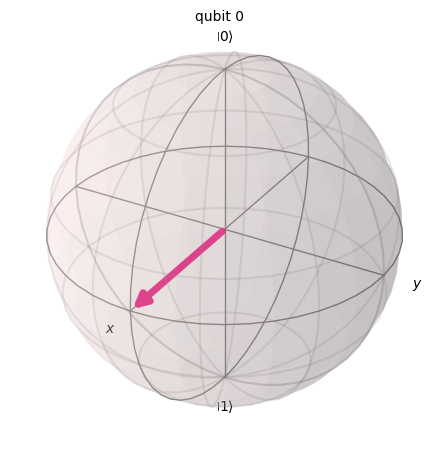


X
   ┌───┐
q: ┤ X ├
   └───┘


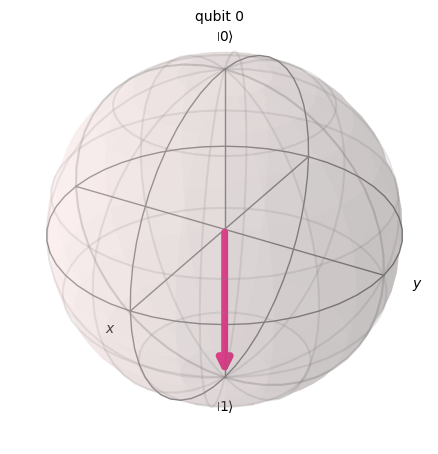


H then X
   ┌───┐┌───┐
q: ┤ H ├┤ X ├
   └───┘└───┘


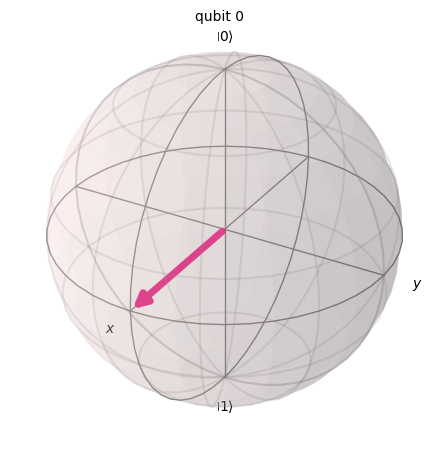


H then Z
   ┌───┐┌───┐
q: ┤ H ├┤ Z ├
   └───┘└───┘


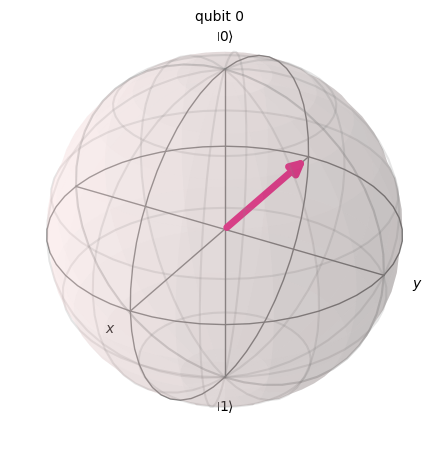


H then S
   ┌───┐┌───┐
q: ┤ H ├┤ S ├
   └───┘└───┘


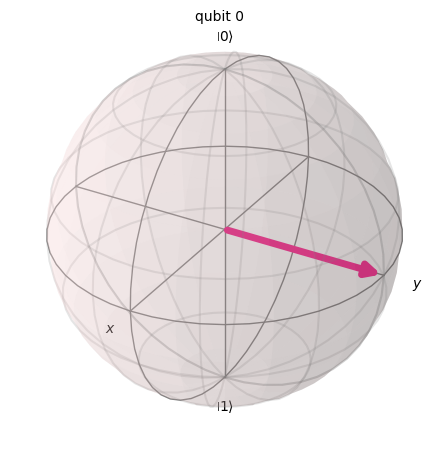

In [71]:
gate_sets = {
    "H": ["h"],
    "X": ["x"],
    "H then X": ["h", "x"],
    "H then Z": ["h", "z"],
    "H then S": ["h", "s"]
}

for name, gates in gate_sets.items():
    qc = QuantumCircuit(1)
    for gate in gates:
        getattr(qc, gate)(0)
    print(f"\n{name}")
    print(qc)
    state = Statevector.from_instruction(qc)
    display(plot_bloch_multivector(state))


### Reflection
Choose any **two** gate sequences above and explain:
- where the state ended up
### H then Z = negative X-axis. H then S = Positive y-axis
- whether the move looked like a flip or a rotation
### H then Z = rotation. H then S = Positive y-axis
- what you learned from the comparison
### H then X is a rotation in its on position because X gate does not change the probabilities
### H then Z changes the relative phase of 180° between $|0\rangle$ and $|1\rangle$. So, $\left|\beta\right|^2=\left|-\beta\right|^2$


# Student mini-challenge

H - T - S 
   ┌───┐┌───┐┌───┐
q: ┤ H ├┤ T ├┤ S ├
   └───┘└───┘└───┘


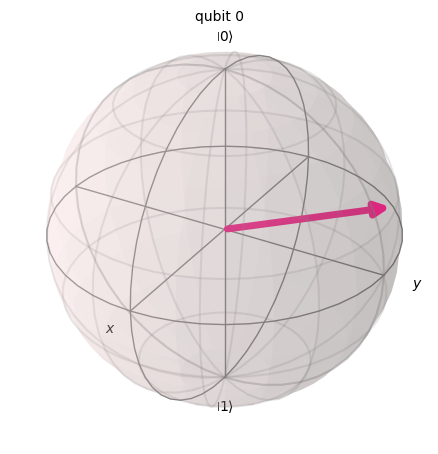

In [89]:
# Example template for your own circuit

'''- `x`
- `y`
- `z`
- `h`
- `s`
- `t`'''

qc = QuantumCircuit(1)

qc.h(0)
qc.t(0)
qc.s(0)

print(f"H - T - S \n{qc}")
      
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

## Reflection

1. the gates you used
### H - T - S
2. what you predicted
### I predicted that the state would remain on the equator and rotate according to the phase added by the T and S gates.
3. what actually happened
### The state remained on the equator and moved to a position with phase $(3\pi/4)$, which is between the negative X-axis and the positive Y-axis ($\frac{\pi}{4}+\frac{\pi}{2}=\frac{3\pi}{4}=135°$).
4. whether the result matched your expectation
### yes

## Part 13: Final summary questions


1. What does the Bloch Sphere help us visualize?
### Visualize the phases' behavior of a single qubit through gates
2. What is the difference between basis states and superposition states on the sphere?
### Basis states lie at the poles of the z-axis, with $|0\rangle$ at the north pole and $|1\rangle$ at the south pole. Superposition states lie between these poles, and equal superposition states are found on the equator.
3. Which gate in this activity caused a clear flip between poles?
### X 
4. Which gate sequence helped you understand phase?
### H T S
5. Why is the Bloch Sphere mainly useful for single-qubit states?
### for a single qubit, the bloch sphere offers 3d which its necessary for this task, more than one qubit the dimensions increase exponential of two, making it complicate to map and read  